[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DavidNaranjo1237/NATICUSdroid/blob/main/notebooks/02_random_forest.ipynb)

Abrir este notebook en Google Colab para ejecutar el modelo de Random Forest de forma autónoma.

# 02. Random Forest NATICUSdroid

Este notebook entrena y compara un Random Forest con una estrategia incremental basada en un vector de revisión (inspirada en Feng & Zhang).

## 1. Entorno y carga

Centralizamos todos los imports y la detección de Colab aquí.

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Any, Dict, List

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

_bootstrap_dependencies = (np, pd, RandomForestClassifier, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, GridSearchCV, StratifiedKFold)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')

def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()

repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.' )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Repository root: {repo_root}')
print('Imports listos para el entrenamiento del Random Forest.')

Bootstrap imports loaded: 12
Repository root: c:\Users\EXITOPC\Desktop\Modelos2
Imports listos para el entrenamiento del Random Forest.


## 2. Preprocesado 



In [3]:
from src.prepare_data import prepare_dataset

results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']

print('Artefactos generados:')
for name, value in artifacts.items():
    print(f'{name}: {value}')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

Artefactos generados:
train_features: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\X_train.csv
test_features: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\X_test.csv
train_target: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\y_train.csv
test_target: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\y_test.csv
train_full: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\train.csv
test_full: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\test.csv
metadata: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\split_metadata.json
X_train shape: (20532, 86)
X_test shape: (8800, 86)
y_train shape: (20532,)
y_test shape: (8800,)


## 3. Resumen visual del dataset

Vista rápida de tamaño, balance de clases y ejemplos.

             Métrica  Valor
               Filas  29332
    Columnas totales     87
Variables de entrada     86
   Valores faltantes      0
             Clase 0  14632
             Clase 1  14700
Primeras 10 filas:
 android.permission.GET_ACCOUNTS  com.sonyericsson.home.permission.BROADCAST_BADGE  android.permission.READ_PROFILE  android.permission.MANAGE_ACCOUNTS  android.permission.WRITE_SYNC_SETTINGS  android.permission.READ_EXTERNAL_STORAGE  android.permission.RECEIVE_SMS  com.android.launcher.permission.READ_SETTINGS  android.permission.WRITE_SETTINGS  com.google.android.providers.gsf.permission.READ_GSERVICES  android.permission.DOWNLOAD_WITHOUT_NOTIFICATION  android.permission.GET_TASKS  android.permission.WRITE_EXTERNAL_STORAGE  android.permission.RECORD_AUDIO  com.huawei.android.launcher.permission.CHANGE_BADGE  com.oppo.launcher.permission.READ_SETTINGS  android.permission.CHANGE_NETWORK_STATE  com.android.launcher.permission.INSTALL_SHORTCUT  android.permission.android.permi

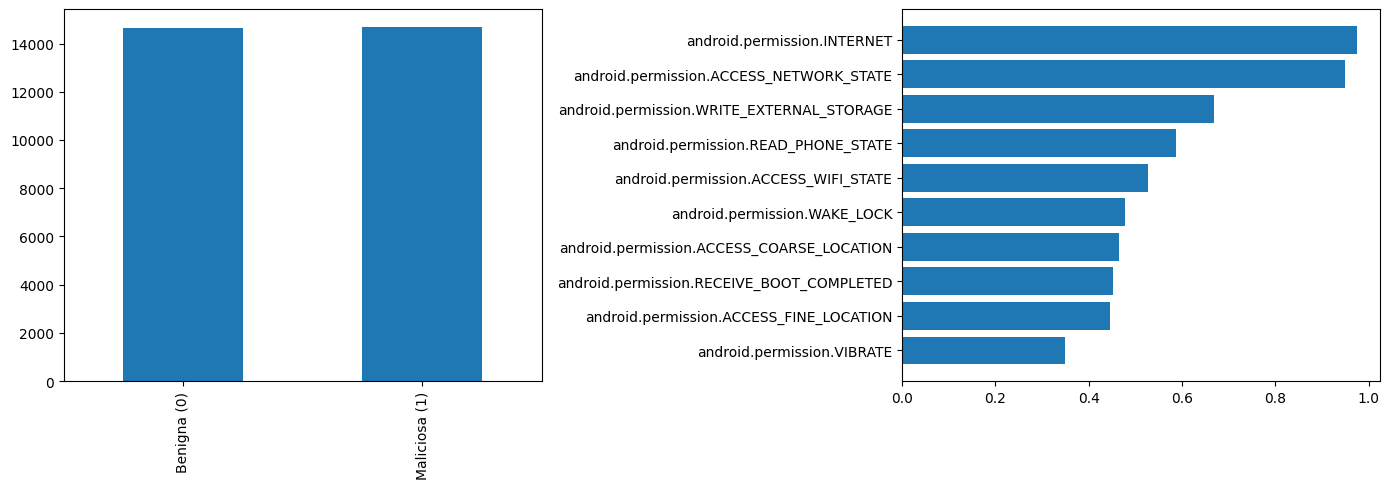

In [4]:
train_df = X_train.copy()
train_df['Result'] = y_train.values

summary_table = pd.DataFrame([
    ['Filas', summary['rows']],
    ['Columnas totales', summary['columns']],
    ['Variables de entrada', summary['feature_columns']],
    ['Valores faltantes', summary['missing_values']],
    ['Clase 0', summary['class_distribution']['0']],
    ['Clase 1', summary['class_distribution']['1']],
], columns=['Métrica', 'Valor'])
print(summary_table.to_string(index=False))

print('Primeras 10 filas:')
print(train_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts = pd.Series(summary['class_distribution']).astype(int)
class_counts.index = ['Benigna (0)', 'Maliciosa (1)']
class_counts.plot(kind='bar', ax=axes[0])
feature_prevalence = X_train.mean().sort_values(ascending=False).head(10)
axes[1].barh(feature_prevalence.index[::-1], feature_prevalence.values[::-1])
plt.tight_layout()
plt.show()

## 4. Funciones auxiliares

Funciones reutilizables: métricas, selección de vector, ajuste y evaluación.

In [5]:
def compute_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'roc_auc': roc_auc_score(y_true, y_score),
    }

def metric_report(strategy, split_name, metrics_dict):
    frame = pd.DataFrame([metrics_dict])
    frame.insert(0, 'split', split_name)
    frame.insert(0, 'strategy', strategy)
    return frame

def select_feature_vector(model, feature_names, cumulative_threshold=0.90, min_features=20):
    importance_series = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    normalized = importance_series / importance_series.sum()
    cumulative = normalized.cumsum()
    selected_features = normalized.index[cumulative <= cumulative_threshold].tolist()
    if len(selected_features) < min_features:
        selected_features = normalized.head(min_features).index.tolist()
    importance_table = pd.DataFrame({
        'feature': normalized.index,
        'importance': normalized.values,
        'cumulative_importance': cumulative.values,
    })
    return importance_table, selected_features

def fit_random_forest(X_fit, y_fit, params):
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_fit, y_fit)
    return model

def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_score = model.predict_proba(X_eval)[:, 1]
    return compute_metrics(y_eval, y_pred, y_score), y_pred, y_score

## 5. Entrenamiento y comparación

Ajuste del Random Forest  y comparación con la versión incremental. (tardó 6 min en local y 22 min en Colab )

In [6]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': [None, 'balanced_subsample'],
}
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
search = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), param_grid=param_grid, scoring='f1', cv=cv_strategy, n_jobs=1, return_train_score=True)
search.fit(X_train, y_train)
best_model = search.best_estimator_
best_params = search.best_params_
print('Mejores hiperparámetros encontrados:', best_params)
baseline_train_metrics, _, _ = evaluate_model(best_model, X_train, y_train)
baseline_test_metrics, _, _ = evaluate_model(best_model, X_test, y_test)
baseline_table = pd.concat([metric_report('RF base','Train', baseline_train_metrics), metric_report('RF base','Test', baseline_test_metrics)], ignore_index=True)
print('Resultados base:')
print(baseline_table.to_string(index=False))

Mejores hiperparámetros encontrados: {'class_weight': 'balanced_subsample', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Resultados base:
strategy split  accuracy  precision   recall       f1  specificity  roc_auc
 RF base Train  0.981200   0.985110 0.977259 0.981169     0.985159 0.996975
 RF base  Test  0.970341   0.971799 0.968934 0.970364     0.971754 0.994246


## 6. Ajuste incremental al estilo Feng y Zhang

En el paper de Feng y Zhang, la idea central no es volver a entrenar todo desde cero cada vez que llega nueva información, sino conservar una memoria representativa del pasado y actualizar la representación con el nuevo bloque para reentrenar sobre un conjunto ampliado. Aquí hacemos una versión aproximda a esa idea: simulamos el crecimiento del dataset con un script, construimos una memoria replay, unimos historia + lote nuevo y volvemos a entrenar desde cero sobre el subconjunto actualizado. Además, seleccionamos las variables más informativas usando tanto el histórico como el lote nuevo para que el vector refleje mejor la distribución actual.

Rondas de actualización simuladas: 3
Muestras que quedan como base histórica: 17454
  Ronda 1: 1026 muestras nuevas
  Ronda 2: 1026 muestras nuevas
  Ronda 3: 1026 muestras nuevas
Número de variables seleccionadas: 20
Primeras variables seleccionadas: ['android.permission.READ_PHONE_STATE', 'com.google.android.c2dm.permission.RECEIVE', 'android.permission.RECEIVE_BOOT_COMPLETED', 'com.android.launcher.permission.INSTALL_SHORTCUT', 'android.permission.ACCESS_COARSE_LOCATION', 'android.permission.GET_TASKS', 'android.permission.ACCESS_FINE_LOCATION', 'android.permission.SYSTEM_ALERT_WINDOW', 'com.android.vending.BILLING', 'android.permission.READ_EXTERNAL_STORAGE']
Muestras de replay: 5749
Muestras del nuevo lote: 1026
Comparación entre el modelo base y el ajuste incremental:
          strategy split  accuracy  precision   recall       f1  specificity  roc_auc
           RF base Train  0.981200   0.985110 0.977259 0.981169     0.985159 0.996975
           RF base  Test  0.970341   0.9717

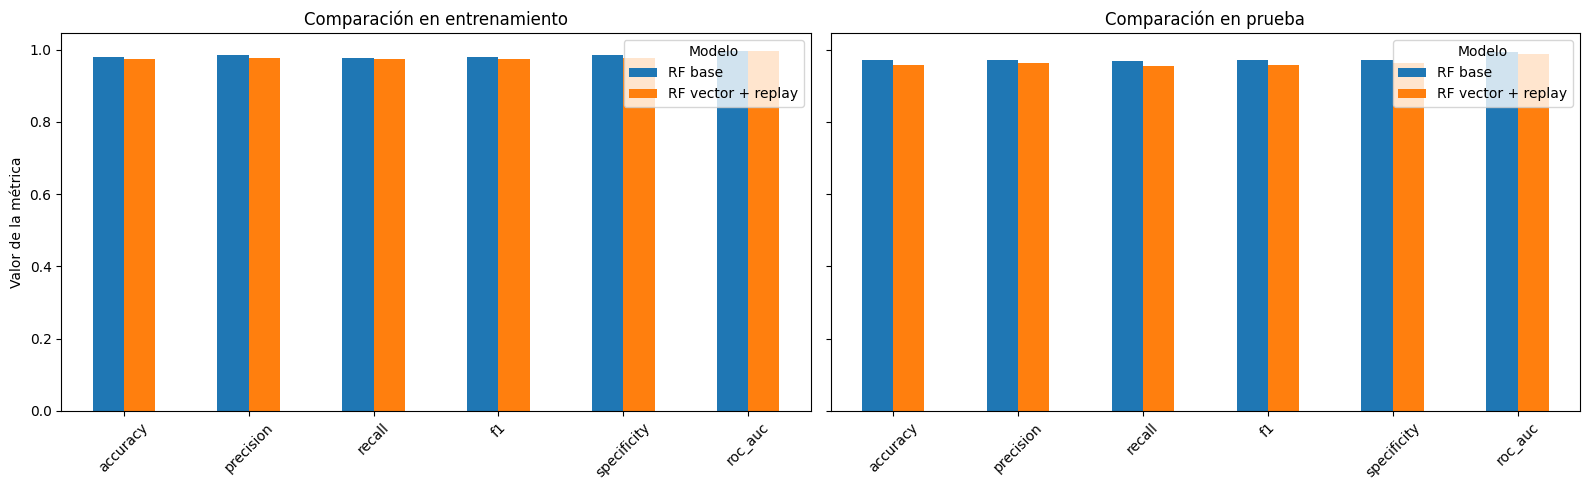

Estado del vector guardado en c:\Users\EXITOPC\Desktop\Modelos2\data\processed\replay_state_example.json


In [ ]:
from datetime import datetime, timezone
from src.replay_update import (
    ReplayVectorState,
    build_replay_subset,
    save_state,
    select_features_advanced,
    simulate_growth,
)

# 1) Simulamos el crecimiento del dataset sin tocar el CSV original.
# Ejemplo: si el dataset tiene 70,000 filas y update_size = 0.05,
# entonces cada ronda nueva aporta 3,500 filas (el 5% del total).
# n_rounds define cuántas rondas de actualización vamos a generar.
updates, X_remain, y_remain = simulate_growth(X_train, y_train, n_rounds=3, update_size=0.05, seed=42)
print(f'Rondas de actualización simuladas: {len(updates)}')
print(f'Muestras que quedan como base histórica: {len(X_remain)}')
for ronda, (X_nuevo, _) in enumerate(updates, start=1):
    print(f'  Ronda {ronda}: {len(X_nuevo)} muestras nuevas')

# 2) Tomamos una memoria histórica y el primer lote nuevo para construir el vector.
# Aquí usamos una parte del histórico como base y la combinamos con el lote entrante.
X_hist = X_train.iloc[:int(0.8 * len(X_train))].copy()
y_hist = y_train.iloc[:int(0.8 * len(y_train))].copy()
X_lote_nuevo, y_lote_nuevo = updates[0]
X_lote_nuevo = X_lote_nuevo.copy()
y_lote_nuevo = y_lote_nuevo.copy()

# 3) Seleccionamos un vector de características usando histórico + lote nuevo.
# cumulative_threshold=0.80 significa que nos quedamos con las variables más
# importantes hasta reunir el 80% de la importancia total. Ejemplo: si las primeras
# variables ya explican 82%, dejamos de añadir más.
# min_features=15 evita que el vector quede demasiado corto: si el 80% se alcanza
# antes, igual mantenemos al menos 15 variables.
X_union_vector = pd.concat([X_hist, X_lote_nuevo], axis=0).reset_index(drop=True)
y_union_vector = pd.concat([y_hist, y_lote_nuevo], axis=0).reset_index(drop=True)
tabla_vectores, selected_features = select_features_advanced(
    X_union_vector,
    y_union_vector,
    model=best_model,
    method='combined',
    cumulative_threshold=0.80,
    min_features=15,
)
print(f'Número de variables seleccionadas: {len(selected_features)}')
print('Primeras variables seleccionadas:', selected_features[:10])

# 4) Construimos la memoria replay y el bloque incremental solo sobre las variables seleccionadas.
# replay_rate=0.35 indica qué parte del histórico guardamos como memoria para no
# olvidar el patrón previo. Ejemplo: si hay 10,000 filas históricas, se conservan 3,500.
replay_rate = 0.35
X_replay, y_replay = build_replay_subset(X_hist[selected_features], y_hist, replay_rate=replay_rate, seed=42)
X_lote_nuevo = X_lote_nuevo[selected_features].copy()
print(f'Muestras de replay: {len(X_replay)}')
print(f'Muestras del nuevo lote: {len(X_lote_nuevo)}')

# 5) Reentrenamos desde cero con replay + nuevo lote.
X_incremental = pd.concat([X_replay, X_lote_nuevo], axis=0).reset_index(drop=True)
y_incremental = pd.concat([y_replay, y_lote_nuevo], axis=0).reset_index(drop=True)
incremental_model = fit_random_forest(X_incremental, y_incremental, best_params)
incremental_train_metrics, _, _ = evaluate_model(incremental_model, X_incremental, y_incremental)
incremental_test_metrics, _, _ = evaluate_model(incremental_model, X_test[selected_features], y_test)

# 6) Comparamos contra el modelo base.
tabla_base = baseline_table.copy()
tabla_incremental = pd.concat([
    metric_report('RF vector + replay', 'Train', incremental_train_metrics),
    metric_report('RF vector + replay', 'Test', incremental_test_metrics),
], ignore_index=True)
tabla_comparativa = pd.concat([tabla_base, tabla_incremental], ignore_index=True)
print('Comparación entre el modelo base y el ajuste incremental:')
print(tabla_comparativa.to_string(index=False))

# 6.1 Gráficas de comparación para train y test.
metricas_a_comparar = ['accuracy', 'precision', 'recall', 'f1', 'specificity', 'roc_auc']
comparacion_train = pd.DataFrame({
    'métrica': metricas_a_comparar,
    'RF base': [baseline_train_metrics[m] for m in metricas_a_comparar],
    'RF vector + replay': [incremental_train_metrics[m] for m in metricas_a_comparar],
})
comparacion_test = pd.DataFrame({
    'métrica': metricas_a_comparar,
    'RF base': [baseline_test_metrics[m] for m in metricas_a_comparar],
    'RF vector + replay': [incremental_test_metrics[m] for m in metricas_a_comparar],
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
comparacion_train.set_index('métrica').plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Comparación en entrenamiento')
axes[0].set_xlabel('')
axes[0].set_ylabel('Valor de la métrica')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Modelo')
comparacion_test.set_index('métrica').plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Comparación en prueba')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Modelo')
plt.tight_layout()
plt.show()

# 7) Guardamos el estado del vector para reutilizarlo en otra sesión.
estado_vector = ReplayVectorState(
    selected_features=selected_features,
    replay_rate=replay_rate,
    best_params=best_params,
    historical_size=len(X_hist),
    update_size=len(X_lote_nuevo),
    selection_method='combined',
    threshold=0.80,
    min_features=15,
    created_at=datetime.now(timezone.utc).isoformat(),
)
output_state_path = repo_root / 'data' / 'processed' / 'replay_state_example.json'
save_state(str(output_state_path), estado_vector.__dict__)
print(f'Estado del vector guardado en {output_state_path}')